<a href="https://colab.research.google.com/github/anupamchaudhary-rgb/Workshoppython/blob/main/Experiment_11.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.0/46.0 kB 3.0 MB/s eta 0:00:00
PRODUCT MANUFACTURING RECORD
----------------------------
Part ID: P101
Component: Spur Gear
Material: EN8 Steel
Machine: CNC-03
Batch Number: B2026-07
Manufacturing Date: 29-07-2026
Operator: Operator-01
Inspection Status: PASS
Revision: R1

QR code generated successfully.


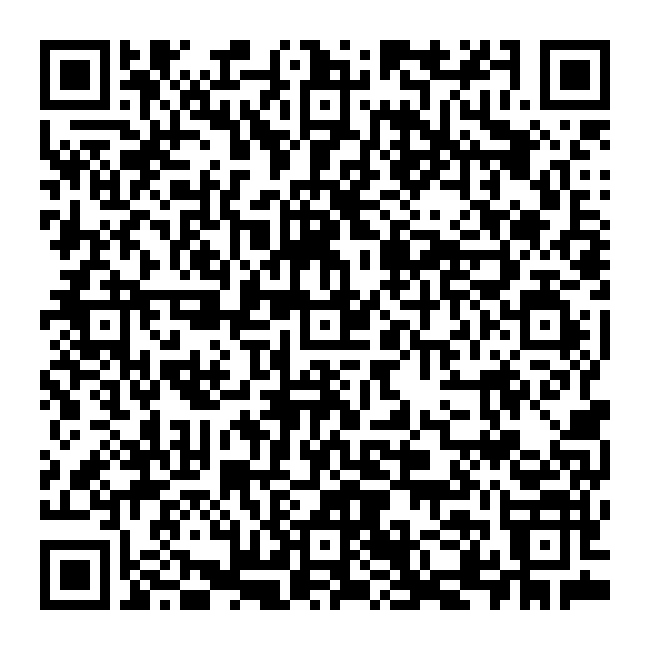

QR CODE SCANNED SUCCESSFULLY
----------------------------
Part ID: P101
Component: Spur Gear
Material: EN8 Steel
Machine: CNC-03
Batch Number: B2026-07
Manufacturing Date: 29-07-2026
Operator: Operator-01
Inspection Status: PASS
Revision: R1



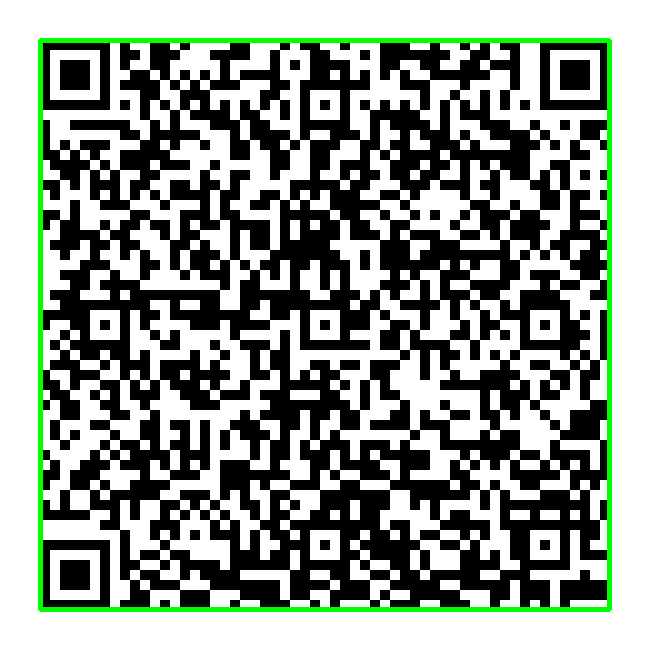

Final result saved as scanned_qr_result.png


In [1]:
# EXPERIMENT 11
# QR CODE-BASED PRODUCT TRACEABILITY USING PYTHON

# Install the QR-code library
!pip install qrcode[pil]

# Import required libraries
import csv
import qrcode
import cv2
from google.colab.patches import cv2_imshow


# Read product information from the CSV file
product_data = ""

with open("product_record.csv", "r") as file:

    reader = csv.DictReader(file)

    for row in reader:

        product_data = (
            product_data
            + row["Field"]
            + ": "
            + row["Value"]
            + "\n"
        )


# Display the manufacturing record
print("PRODUCT MANUFACTURING RECORD")
print("----------------------------")
print(product_data)


# Generate the QR code
qr_image = qrcode.make(product_data)


# Save the QR-code image
qr_image.save("product_qr.png")

print("QR code generated successfully.")


# Read the generated QR-code image
image = cv2.imread("product_qr.png")


# Display the QR code
cv2_imshow(image)


# Create a QR-code detector
detector = cv2.QRCodeDetector()


# Decode the QR code
decoded_data, points, _ = detector.detectAndDecode(image)


# Display the decoded information
if decoded_data != "":

    print("QR CODE SCANNED SUCCESSFULLY")
    print("----------------------------")
    print(decoded_data)

else:

    print("QR code could not be read.")


# Draw a green boundary around the detected QR code
if points is not None:

    points = points[0].astype(int)

    for i in range(4):

        point1 = tuple(points[i])

        point2 = tuple(
            points[(i + 1) % 4]
        )

        cv2.line(
            image,
            point1,
            point2,
            (0, 255, 0),
            4
        )


    # Display the detected QR code
    cv2_imshow(image)


    # Save the final result
    cv2.imwrite(
        "scanned_qr_result.png",
        image
    )

    print(
        "Final result saved as scanned_qr_result.png"
    )